M30 PArte 2


Neste exercício vamos usar a base [online shoppers purchase intention](https://archive.ics.uci.edu/ml/datasets/Online+Shoppers+Purchasing+Intention+Dataset) de Sakar, C.O., Polat, S.O., Katircioglu, M. et al. Neural Comput & Applic (2018). [Web Link](https://doi.org/10.1007/s00521-018-3523-0).

A base trata de registros de 12.330 sessões de acesso a páginas, cada sessão sendo de um único usuário em um período de 12 meses, para posteriormente estudarmos a relação entre o design da página e o perfil do cliente - "Será que clientes com comportamento de navegação diferentes possuem propensão a compra diferente?"

Nosso objetivo é tentar agrupar os clientes conforme seu comportamento de navegação entre páginas administrativas, informativas e de produtos.

As variáveis estão descritas abaixo (em tradução livre do link indicado).

Por este motivo, o escopo desta análise estará fechado nas primeiras seis variáveis da tabela, referentes a quantidade e tempo de acesso por tipo de página, atributos que falam mais do comportamento de navegação do cliente que de características da página o da época do ano.

|Variavel                |Descrição          |
|------------------------|:-------------------|
|Administrative          | Quantidade de acessos em páginas administrativas|
|Administrative_Duration | Tempo de acesso em páginas administrativas |
|Informational           | Quantidade de acessos em páginas informativas  |
|Informational_Duration  | Tempo de acesso em páginas informativas  |
|ProductRelated          | Quantidade de acessos em páginas de produtos |
|ProductRelated_Duration | Tempo de acesso em páginas de produtos |
|BounceRates             | *Percentual de visitantes que entram no site e saem sem acionar outros *requests* durante a sessão  |
|ExitRates               | * Soma de vezes que a página é visualizada por último em uma sessão dividido pelo total de visualizações |
|PageValues              | * Representa o valor médio de uma página da Web que um usuário visitou antes de concluir uma transação de comércio eletrônico |
|SpecialDay              | Indica a proximidade a uma data festiva (dia das mães etc) |
|Month                   | Mês  |
|OperatingSystems        | Sistema operacional do visitante |
|Browser                 | Browser do visitante |
|Region                  | Região |
|TrafficType             | Tipo de tráfego                  |
|VisitorType             | Tipo de visitante: novo ou recorrente |
|Weekend                 | Indica final de semana |
|Revenue                 | Indica se houve compra ou não |

\* variávels calculadas pelo google analytics

In [ ]:
#Importando Bibliotecas
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

**Análise Descritiva**

In [1]:
# IMPORTAÇÃO
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram

In [3]:
import pandas as pd
df = pd.read_csv('online_shoppers_intention.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'online_shoppers_intention.csv'

In [ ]:
# K-MEANS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
# 1) CARREGAR O DATASET

df = pd.read_csv('online_shoppers_intention.csv')
print("Shape da base:", df.shape)
df.head()

Shape da base: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [7]:
import pandas as pd

# Ensure df is loaded before checking for null values
try:
    # Try to use existing df if it's already defined
    df.head()
except NameError:
    # If df is not defined, load it using the absolute path for robustness
    df = pd.read_csv('/content/online_shoppers_intention.csv')

print('Valores ausentes no DataFrame df:')
display(df.isnull().sum())

Valores ausentes no DataFrame df:


,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


In [6]:
# VISÃO GERAL
print('\nCOLUNAS DISPONÍVEIS')
print(df.columns.tolist())

print('\nINFORMAÇÕES')
print(df.info())

print('\nVALORES NULOS')
print(df.isnull().sum())

print('\nESTATÍSTICAS')
display(df.describe())


COLUNAS DISPONÍVEIS


NameError: name 'df' is not defined

2) Seleção das 6 variáveis de navegação

In [ ]:
cols_navegacao = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration"
]

X = df[cols_navegacao].copy()
X.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration
0,0,0.0,0,0.0,1,0.000000
1,0,0.0,0,0.0,2,64.000000
2,0,0.0,0,0.0,1,0.000000
3,0,0.0,0,0.0,2,2.666667
4,0,0.0,0,0.0,10,627.500000


In [8]:
cols_navegacao = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration"
]

X = df[cols_navegacao].copy()
print("As 6 variáveis de navegação selecionadas:")
display(X.head())

As 6 variáveis de navegação selecionadas:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration
0,0,0.0,0,0.0,1,0.000000
1,0,0.0,0,0.0,2,64.000000
2,0,0.0,0,0.0,1,0.000000
3,0,0.0,0,0.0,2,2.666667
4,0,0.0,0,0.0,10,627.500000


In [9]:
#EXPLICACÃO DE VARIÁVEIS
descricao = pd.DataFrame({
    'Variável':df.columns
})

display(descricao)

,Variável
0,Administrative
1,Administrative_Duration
2,Informational
3,Informational_Duration
4,ProductRelated
5,ProductRelated_Duration
6,BounceRates
7,ExitRates
8,PageValues
9,SpecialDay


In [10]:
#TRATAMENTO

dados = df.copy()

In [11]:
# Codificação das variáveis categóricas

categoricas = [
    'Month',
    'VisitorType',
    'Weekend'
]

for coluna in categoricas:

    encoder = LabelEncoder()

    dados[coluna] = encoder.fit_transform(
        dados[coluna].astype(str)
    )

3) Padronização (obrigatória para K-means)

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

4) Método do Cotovelo

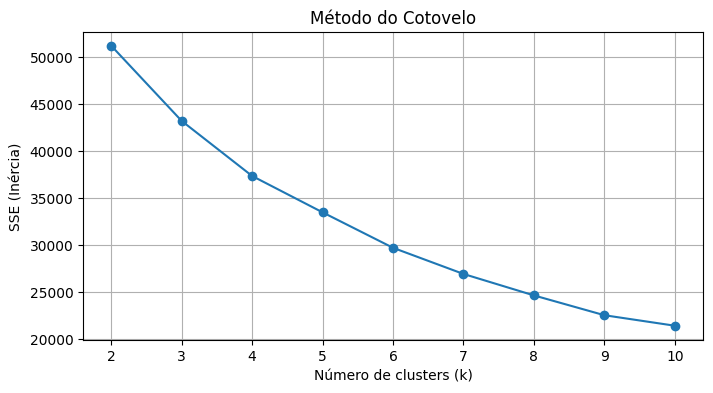

In [ ]:
k_range = range(2, 11)
inertia = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("SSE (Inércia)")
plt.title("Método do Cotovelo")
plt.grid()
plt.show()

### Interpretação do Método do Cotovelo
Interpretação do Método do Cotovelo

O Método do Cotovelo foi utilizado para identificar a quantidade ideal de clusters para segmentar os dados. Nesse método, observamos como a inércia (SSE – Soma dos Erros Quadráticos) diminui à medida que aumentamos o número de grupos.

No gráfico, percebe-se que a redução da inércia é bastante significativa até aproximadamente 3 ou 4 clusters. A partir desse ponto, os ganhos passam a ser menores, indicando que adicionar mais grupos não melhora substancialmente a qualidade da segmentação.

Assim, a formação de 3 ou 4 clusters representa um bom equilíbrio entre simplicidade e capacidade de diferenciar os perfis de consumidores, permitindo uma segmentação eficiente sem tornar o modelo excessivamente complexo.

In [12]:
# VARIÁVEIS PARA CLUSTERIZAÇÃO


features = [

    'Administrative',
    'Administrative_Duration',

    'Informational',
    'Informational_Duration',

    'ProductRelated',
    'ProductRelated_Duration',

    'BounceRates',
    'ExitRates',

    'PageValues',

    'SpecialDay',

    'Month',

    'Weekend'

]

X = dados[features]


### Re-Padronização dos Dados

Como o conjunto de features `X` foi atualizado (agora inclui mais variáveis), é crucial re-aplicar a padronização para garantir que todas as variáveis contribuam igualmente para o cálculo das distâncias no algoritmo K-Means.

In [13]:
scaler_new = StandardScaler()
X_scaled_new = scaler_new.fit_transform(X)

print('Shape do X_scaled com as novas features:', X_scaled_new.shape)

Shape do X_scaled com as novas features: (12330, 12)


### Re-executando o Método do Cotovelo
Re-executado o Método do Cotovelo com o novo X_scaled_new para verificar se o ponto de inflexão muda com as features adicionais.

In [16]:
# PADRONIZAÇÃO


scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

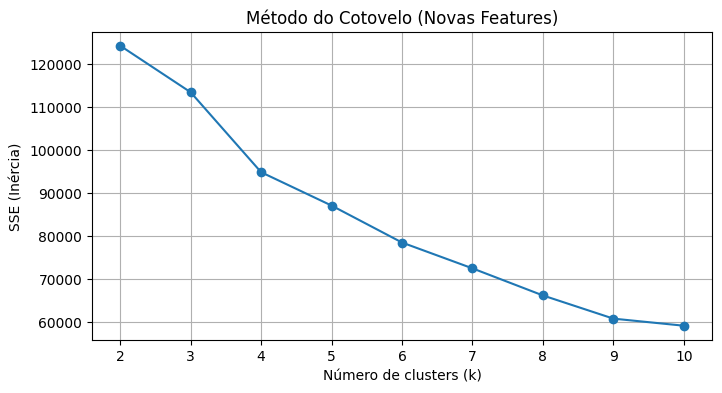

In [17]:
from sklearn.cluster import KMeans # Adicionado para garantir que KMeans seja definido

k_range_new = range(2, 11)
inertia_new = []

for k in k_range_new:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled_new)
    inertia_new.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(k_range_new, inertia_new, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("SSE (Inércia)")
plt.title("Método do Cotovelo (Novas Features)")
plt.grid()
plt.show()

### Re-executando o Método da Silhueta

Agora, vamos re-executar o Método da Silhueta com o novo `X_scaled_new` para ter uma segunda métrica de avaliação e determinar o `k` ideal.

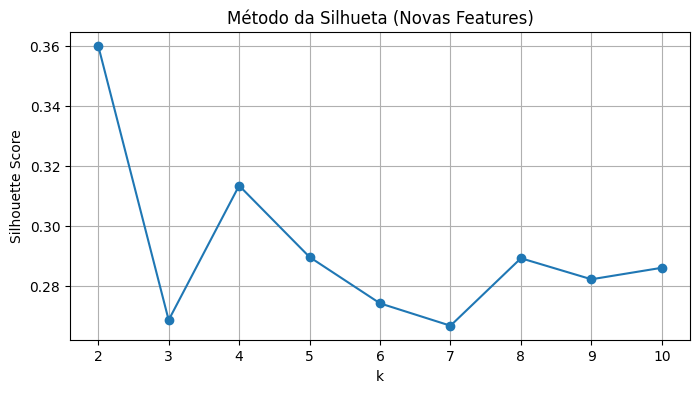

Melhor k segundo Silhueta (Novas Features): 2


In [18]:
from sklearn.cluster import KMeans # Adicionado para garantir que KMeans seja definido
from sklearn.metrics import silhouette_score # Adicionado para garantir que silhouette_score seja definido
import numpy as np # Adicionado para garantir que np seja definido

silhouette_scores_new = []

for k in k_range_new:
    labels_temp = KMeans(n_clusters=k, random_state=42, n_init='auto').fit_predict(X_scaled_new)
    silhouette_scores_new.append(silhouette_score(X_scaled_new, labels_temp))

plt.figure(figsize=(8,4))
plt.plot(k_range_new, silhouette_scores_new, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Método da Silhueta (Novas Features)")
plt.grid(True)
plt.show()

best_k_new = k_range_new[np.argmax(silhouette_scores_new)]
print("Melhor k segundo Silhueta (Novas Features):", best_k_new)

### 6) Ajustar K-means com o melhor `k` (novas features)

Agora que determinamos o `k` ideal como 2, vamos ajustar o modelo K-Means com 2 clusters usando o `X_scaled_new` e atribuir os rótulos de cluster ao DataFrame `dados` (que é a cópia do `df` com as variáveis categóricas já codificadas).

In [19]:
from sklearn.cluster import KMeans # Importa KMeans novamente por segurança

kmeans_final_new = KMeans(n_clusters=best_k_new, random_state=42, n_init='auto')
labels_final_new = kmeans_final_new.fit_predict(X_scaled_new)

# Atribuir os rótulos de cluster ao DataFrame 'dados'
# Lembrando que 'dados' é a cópia de df com as variáveis categóricas codificadas
dados['cluster'] = labels_final_new

print("DataFrame 'dados' com a nova coluna 'cluster':")
display(dados.head())

DataFrame 'dados' com a nova coluna 'cluster':


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,cluster
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,1,1,1,1,2,0,False,1
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,2,1,2,2,0,False,1
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,4,1,9,3,2,0,False,1
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,2,3,2,2,4,2,0,False,1
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,2,3,3,1,4,2,1,False,1


### 7) Tamanho dos novos clusters

Vamos verificar a distribuição de instâncias em cada um dos dois novos clusters.

In [20]:
print("Tamanho dos novos clusters:")
display(dados['cluster'].value_counts().sort_index())

Tamanho dos novos clusters:


,count
cluster,
0,1927
1,10403


### 8) Perfil médio dos novos clusters

As características de cada cluster, vai calcular o perfil médio das variáveis utilizadas na clusterização para cada grupo.

In [21]:
cluster_profile_new = dados.groupby('cluster')[features].mean()
print("Perfil médio dos novos clusters com base nas features selecionadas:")
display(cluster_profile_new)

Perfil médio dos novos clusters com base nas features selecionadas:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,Weekend
cluster,,,,,,,,,,,,
0,7.174883,293.842181,2.259990,184.604308,90.584328,3557.486780,0.006215,0.019243,9.960933,0.029787,5.537623,0.253243
1,1.414976,41.359183,0.178218,6.662709,20.829857,757.083905,0.025151,0.047487,5.135041,0.067288,5.094780,0.228780


### Análise Complementar: Taxa de Compra por Cluster

Verifique a taxa de compra (Revenue) para cada um dos novos clusters.

In [22]:
# Garantir que 'Revenue' está no DataFrame 'dados' e é numérica
# Assumimos que 'df' foi carregado e 'dados' é uma cópia com codificação de categóricas.
# Se 'Revenue' não foi tratada, fazemos aqui.
if 'Revenue' in df.columns and 'Revenue' not in dados.columns:
    dados['Revenue'] = df['Revenue'].astype(int)
elif 'Revenue' in dados.columns:
    dados['Revenue'] = dados['Revenue'].astype(int)

rev_cluster_new = dados.groupby('cluster')['Revenue'].mean().to_frame()
rev_cluster_new.columns = ["Taxa de compra (Revenue %)"]

print("Taxa de compra por cluster (novas features):")
display(rev_cluster_new)

Taxa de compra por cluster (novas features):


,Taxa de compra (Revenue %)
cluster,
0,0.276077
1,0.132270


### 9) Visualização 2D dos Clusters (usando PCA com as novas features)

Visualização da separação dos clusters em 2D,  aplicando PCA (Análise de Componentes Principais) aos dados X_scaled_new e plotando os resultados.

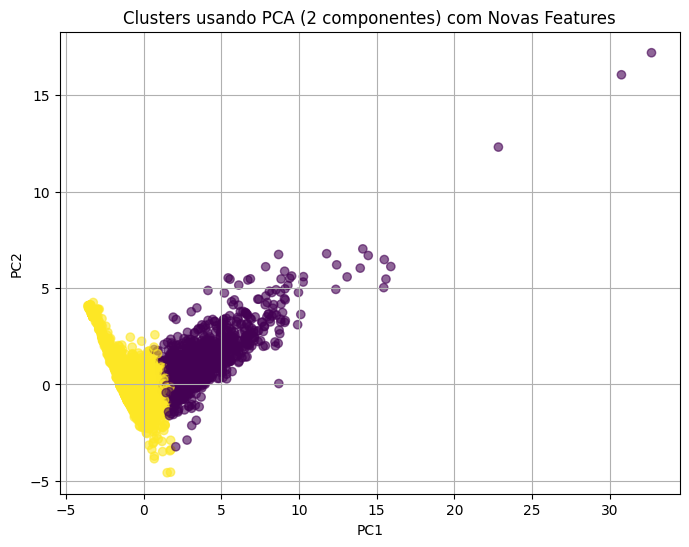

In [23]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca2_new = PCA(n_components=2)
X_pca2_new = pca2_new.fit_transform(X_scaled_new)

plt.figure(figsize=(8,6))
plt.scatter(
    X_pca2_new[:,0],
    X_pca2_new[:,1],
    c=labels_final_new,
    cmap='viridis',
    alpha=0.6
)
plt.title("Clusters usando PCA (2 componentes) com Novas Features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

In [ ]:
# DENDROGRAMA

print('\nGERANDO DENDROGRAMA...')

amostra = X_scaled[:1000]

Z = linkage(
    amostra,
    method='ward'
)

plt.figure(figsize=(15,7))

dendrogram(
    Z,
    truncate_mode='lastp',
    p=20
)

plt.title('Dendrograma Hierárquico')
plt.xlabel('Clusters')
plt.ylabel('Distância')

plt.show()


In [24]:
# CLUSTERIZAÇÃO HIERÁRQUICA

modelo = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward'
)

clusters = modelo.fit_predict(X_scaled)

dados['Cluster'] = clusters


# TAMANHO DOS CLUSTERS


print('\nTAMANHO DOS CLUSTERS')

print(
    dados['Cluster']
    .value_counts()
    .sort_index()
)

# PERFIL DOS CLUSTERS

perfil = dados.groupby(
    'Cluster'
)[features].mean()

print('\nPERFIL DOS CLUSTERS')

display(
    perfil.round(2)
)



TAMANHO DOS CLUSTERS
Cluster
0    9394
1    1197
2    1078
3     661
Name: count, dtype: int64

PERFIL DOS CLUSTERS


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,Weekend
Cluster,,,,,,,,,,,,
0,2.17,62.85,0.28,10.82,28.64,1061.62,0.01,0.03,6.76,0.00,5.12,0.25
1,1.10,32.60,0.22,10.55,25.03,853.76,0.04,0.06,2.01,0.62,5.74,0.13
2,6.36,340.52,3.05,288.26,84.52,3456.95,0.01,0.02,6.19,0.01,5.17,0.19
3,0.02,0.00,0.01,0.00,1.67,14.83,0.20,0.20,0.00,0.00,4.75,0.22



TAXA DE COMPRA


Revenue,0,1
Cluster,,
0,83.30,16.70
1,94.24,5.76
2,75.23,24.77
3,99.55,0.45


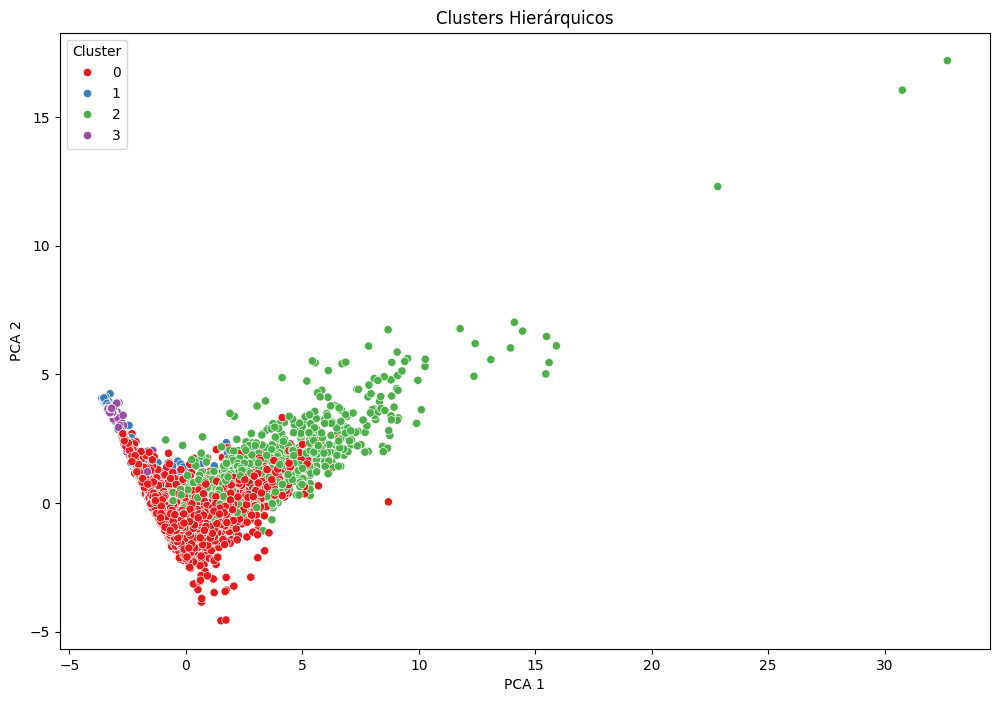

In [25]:
# CONVERSÃO POR CLUSTER

print('\nTAXA DE COMPRA')

conversao = pd.crosstab(

    dados['Cluster'],
    dados['Revenue'],

    normalize='index'

) * 100

display(
    conversao.round(2)
)

# PCA

pca = PCA(n_components=2)

coordenadas = pca.fit_transform(
    X_scaled
)

plt.figure(figsize=(12,8))

sns.scatterplot(

    x=coordenadas[:,0],
    y=coordenadas[:,1],

    hue=dados['Cluster'],
    palette='Set1'

)

plt.title('Clusters Hierárquicos')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')

plt.show()


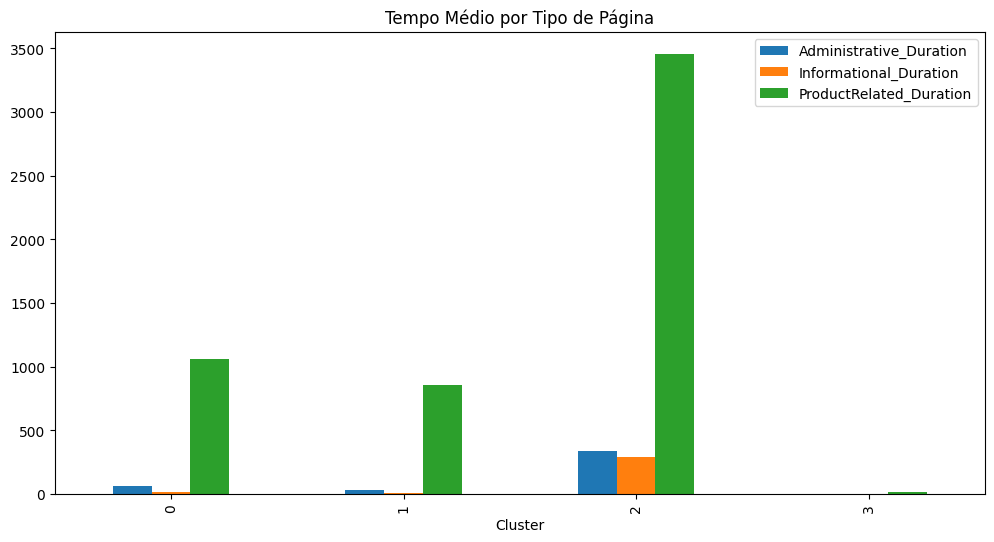

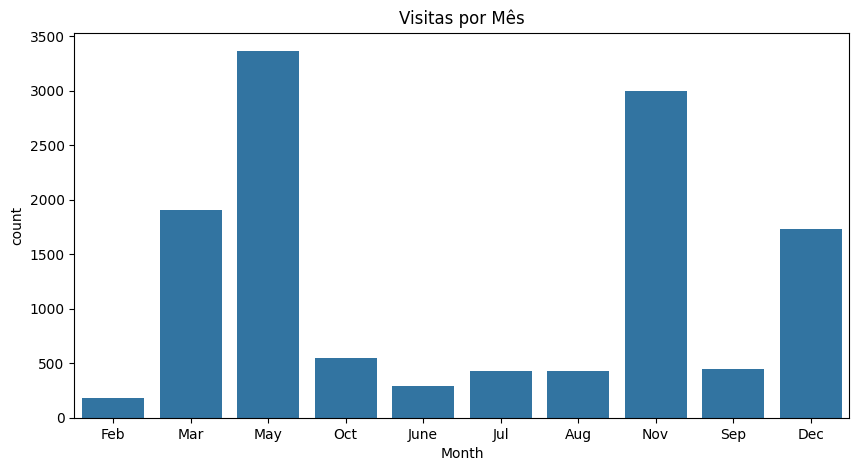

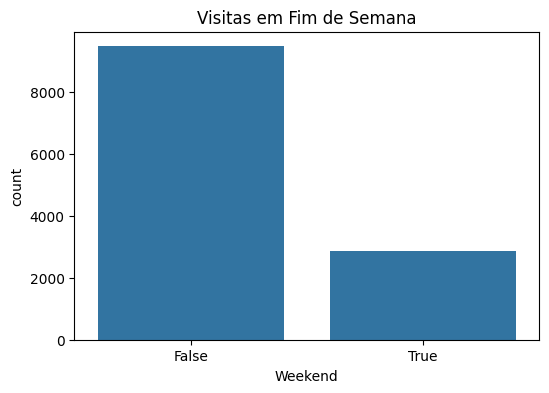

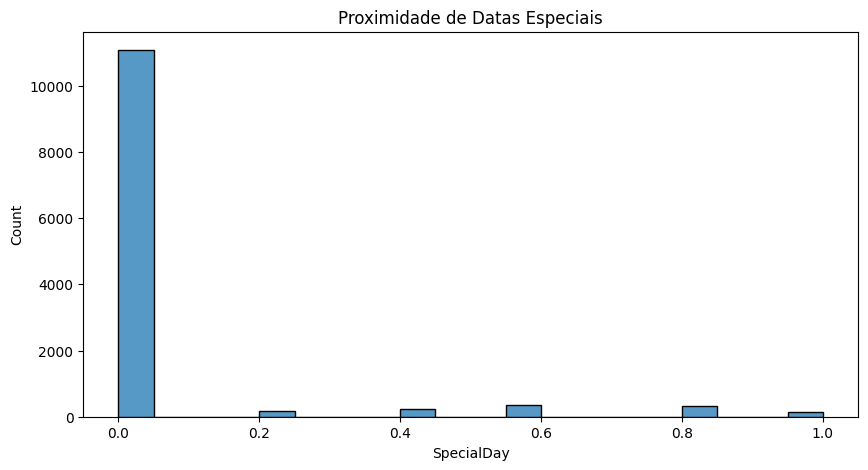


ANÁLISE CONCLUÍDA

O DATASET POSSUI:
- Tipo de página visitada
- Tempo por categoria de página
- Mês da visita
- Fim de semana
- Proximidade de data especial
- Navegador
- Sistema operacional
- Região
- Tipo de visitante
- Compra realizada

O DATASET NÃO POSSUI:


In [31]:
# TEMPO POR TIPO DE PÁGINA

tempo_paginas = dados.groupby(
    'Cluster'
)[
[
'Administrative_Duration',
'Informational_Duration',
'ProductRelated_Duration'
]
].mean()

tempo_paginas.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title(
    'Tempo Médio por Tipo de Página'
)

plt.show()
# MÊS DAS VISITAS

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='Month'
)

plt.title('Visitas por Mês')

plt.show()


# FIM DE SEMANA

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Weekend'
)

plt.title('Visitas em Fim de Semana')

plt.show()

# DATAS ESPECIAIS

plt.figure(figsize=(10,5))

sns.histplot(
    df['SpecialDay'],
    bins=20
)

plt.title(
    'Proximidade de Datas Especiais'
)

plt.show()





IMPACTO DAS DATAS ESPECIAIS


,SpecialDay
Cluster,
0,0.000681
1,0.617544
2,0.010946
3,0.000000


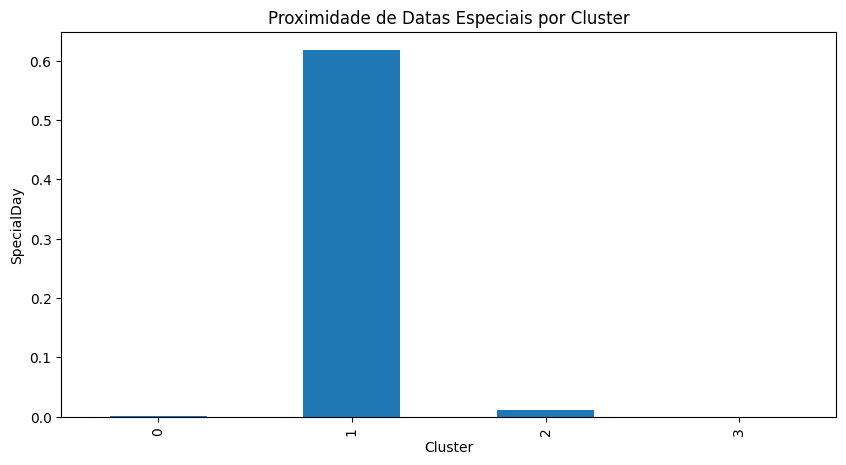

In [36]:
# IMPACTO DAS DATAS ESPECIAIS

print("\n")
print("="*60)
print("IMPACTO DAS DATAS ESPECIAIS")
print("="*60)

especial = dados.groupby(
    'Cluster'
)['SpecialDay'].mean()

display(especial)

plt.figure(figsize=(10,5))

especial.plot(
    kind='bar'
)

plt.title(
    'Proximidade de Datas Especiais por Cluster'
)

plt.ylabel(
    'SpecialDay'
)

plt.show()

In [37]:
# MÊS MAIS FREQUENTE POR CLUSTER

print("\n")
print("="*60)
print("MÊS MAIS FREQUENTE POR CLUSTER")
print("="*60)

for c in sorted(dados['Cluster'].unique()):

    print(f"\nCluster {c}")

    print(
        df[
            dados['Cluster']==c
        ]['Month']
        .value_counts()
        .head(3)
    )



MÊS MAIS FREQUENTE POR CLUSTER

Cluster 0
Month
Nov    2495
May    1900
Mar    1641
Name: count, dtype: int64

Cluster 1
Month
May    1120
Feb      77
Name: count, dtype: int64

Cluster 2
Month
Nov    348
May    192
Dec    181
Name: count, dtype: int64

Cluster 3
Month
Nov    155
May    152
Mar    132
Name: count, dtype: int64


5) Método da Silhueta

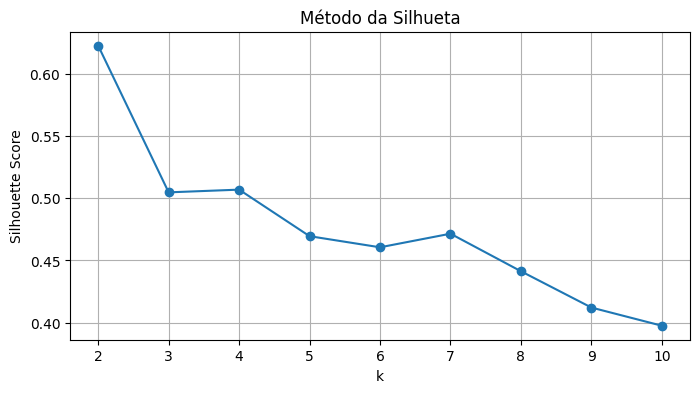

Melhor k segundo Silhueta: 2


In [ ]:
silhouette_scores = []

for k in k_range:
    labels = KMeans(n_clusters=k, random_state=42).fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8,4))
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Método da Silhueta")
plt.grid(True)
plt.show()

best_k = k_range[np.argmax(silhouette_scores)]
print("Melhor k segundo Silhueta:", best_k)

6) Ajustar K-means com o melhor k

In [ ]:
kmeans_final = KMeans(n_clusters=best_k, random_state=42)
labels_final = kmeans_final.fit_predict(X_scaled)

df["cluster"] = labels_final
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,cluster
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False,0


7) Tamanho dos clusters

In [ ]:
print("Tamanho dos clusters:")
df["cluster"].value_counts().sort_index()

Tamanho dos clusters:


,count
cluster,
0,10578
1,1752


8) Perfil médio dos clusters

In [ ]:
cluster_profile = df.groupby("cluster")[cols_navegacao].mean()
cluster_profile

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration
cluster,,,,,,
0,1.494611,44.058464,0.188788,7.037474,21.363490,776.283968
1,7.269406,302.764289,2.404110,200.115446,94.329909,3721.283722


9) Gráfico 2D (Comportamento de produto × duração)

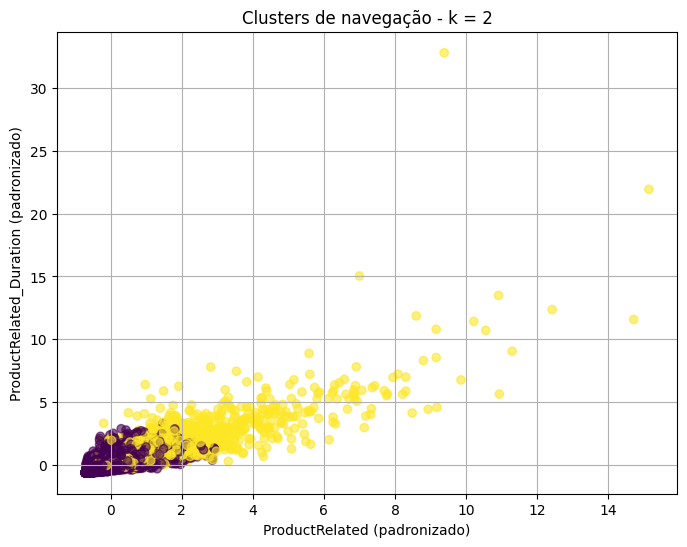

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(
    X_scaled[:, 4],  # ProductRelated
    X_scaled[:, 5],  # ProductRelated_Duration
    c=labels_final,
    cmap='viridis',
    alpha=0.6
)
plt.xlabel("ProductRelated (padronizado)")
plt.ylabel("ProductRelated_Duration (padronizado)")
plt.title(f"Clusters de navegação - k = {best_k}")
plt.grid(True)
plt.show()

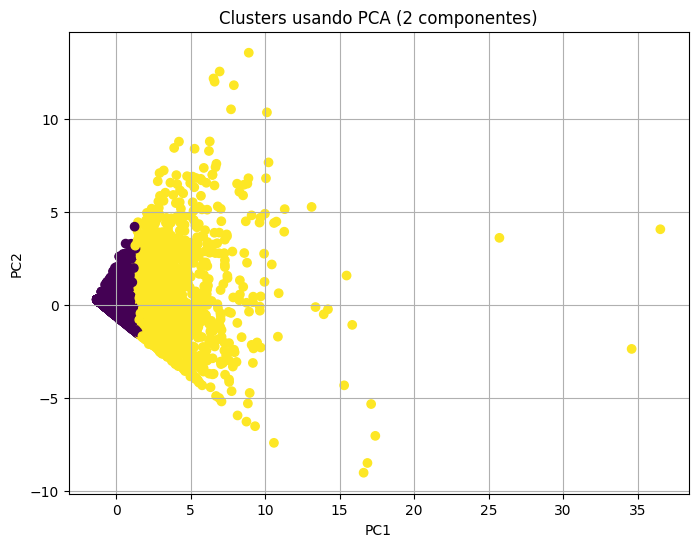

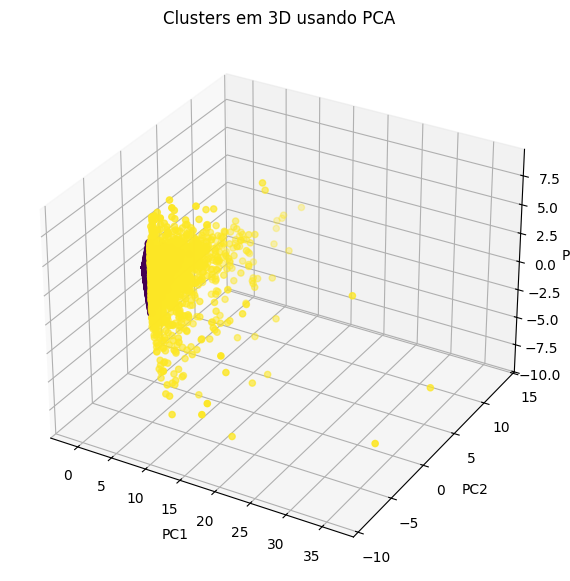

In [ ]:
# Re-import necessary libraries if they were not imported earlier in the session
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# --- Begin: Re-running necessary preceding steps to define X_scaled and labels_final ---

# 1) CARREGAR O DATASET (from n8HsBarokIq8)
try:
    df = pd.read_csv('online_shoppers_intention.csv')
except FileNotFoundError:
    print("Error: 'online_shoppers_intention.csv' not found. Please ensure the file is in the correct directory.")
    raise # Re-raise the error as the notebook cannot proceed without the data

# 2) Seleção das 6 variáveis de navegação (from mO34au-MkNZ1)
cols_navegacao = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration"
]
X = df[cols_navegacao].copy()

# 3) Padronização (obrigatória para K-means) (from 5qHjAVYDkck_)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5) Método da Silhueta - to get best_k (from lvG1PT-IktLO)
k_range = range(2, 11)
silhouette_scores = []
for k in k_range:
    labels_temp = KMeans(n_clusters=k, random_state=42, n_init='auto').fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels_temp))

best_k = k_range[np.argmax(silhouette_scores)]

# 6) Ajustar K-means com o melhor k - to get labels_final (from 1Sdd8Oylkzwk)
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
labels_final = kmeans_final.fit_predict(X_scaled)

# --- End: Re-running necessary preceding steps ---

# Original code for PCA visualization
# PCA 2 componentes
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca2[:,0], X_pca2[:,1], c=labels_final, cmap='viridis')
plt.title("Clusters usando PCA (2 componentes)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

# PCA 3 componentes
pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca3[:,0], X_pca3[:,1], X_pca3[:,2], c=labels_final, cmap='viridis')
ax.set_title("Clusters em 3D usando PCA")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.show()

In [ ]:
df['Revenue'] = df['Revenue'].astype(int)

# Garante que a coluna 'cluster' existe no DataFrame df
# 'labels_final' é esperado estar disponível do kernel após a execução anterior.
if 'cluster' not in df.columns:
    df["cluster"] = labels_final

rev_cluster = df.groupby("cluster")['Revenue'].mean().to_frame()
rev_cluster.columns = ["Taxa de compra (Revenue %)"]
rev_cluster

,Taxa de compra (Revenue %)
cluster,
0,0.135092
1,0.273402


TrafficType,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
cluster,,,,,,,,,,,,,,,,,,,,
0,0.202118,0.295141,0.176593,0.089431,0.022689,0.036491,0.003214,0.028077,0.003687,0.035829,0.021649,0.000095,0.060692,0.001040,0.003403,0.000189,0.000095,0.000945,0.001418,0.017206
1,0.178653,0.451484,0.105023,0.070205,0.011416,0.033105,0.003425,0.026256,0.001712,0.040525,0.010274,0.000000,0.054795,0.001142,0.001142,0.000571,0.000000,0.000000,0.001142,0.009132


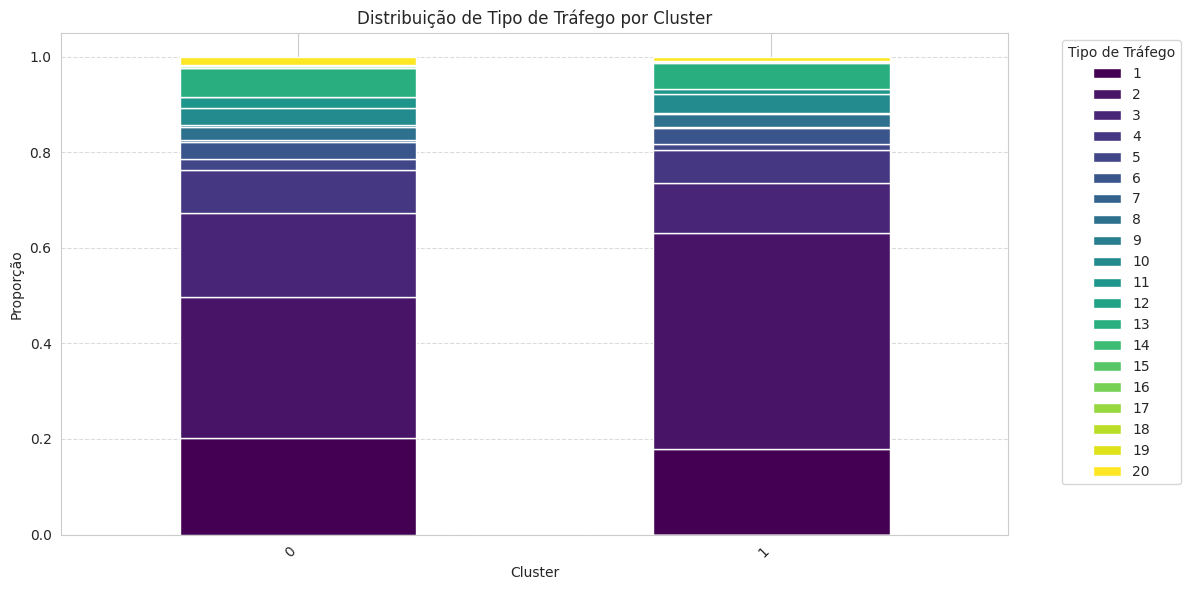

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the distribution of TrafficType within each cluster
traffic_type_distribution = df.groupby('cluster')['TrafficType'].value_counts(normalize=True).unstack(fill_value=0)

# Display the distribution
display(traffic_type_distribution)

# Plot the distribution
traffic_type_distribution.plot(kind='bar', stacked=True, figsize=(12, 6), cmap='viridis')
plt.title('Distribuição de Tipo de Tráfego por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Proporção')
plt.xticks(rotation=45, ha='right') # Ensure x-axis labels are readable
plt.legend(title='Tipo de Tráfego', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

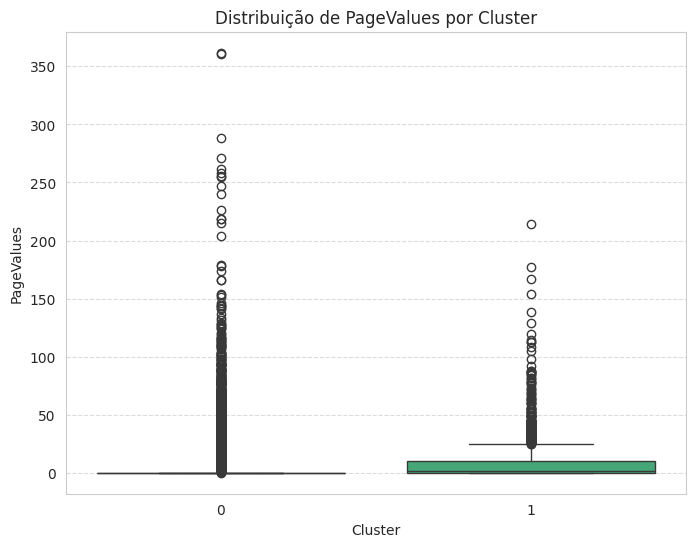

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='cluster', y='PageValues', data=df, palette='viridis', hue='cluster', legend=False)
plt.title('Distribuição de PageValues por Cluster')
plt.xlabel('Cluster')
plt.ylabel('PageValues')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

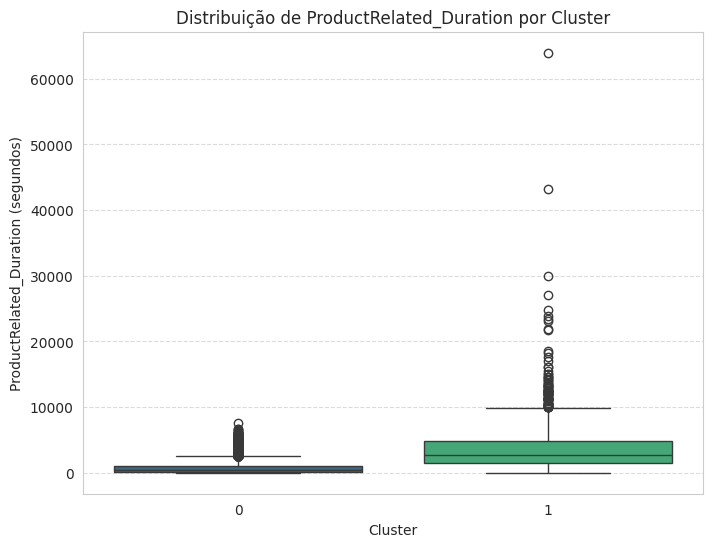

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='cluster', y='ProductRelated_Duration', data=df, palette='viridis', hue='cluster', legend=False)
plt.title('Distribuição de ProductRelated_Duration por Cluster')
plt.xlabel('Cluster')
plt.ylabel('ProductRelated_Duration (segundos)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

VisitorType,New_Visitor,Other,Returning_Visitor
cluster,,,
0,0.150028,0.007752,0.842220
1,0.061073,0.001712,0.937215


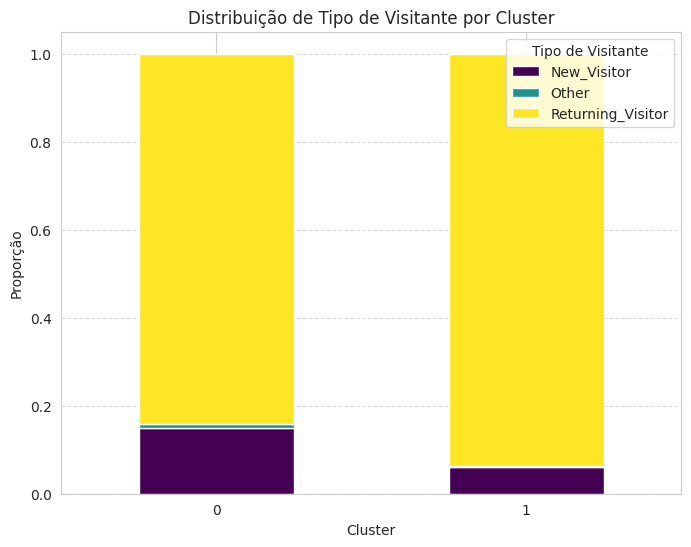

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the distribution of VisitorType within each cluster
visitor_type_distribution = df.groupby('cluster')['VisitorType'].value_counts(normalize=True).unstack(fill_value=0)

# Display the distribution
display(visitor_type_distribution)

# Plot the distribution
visitor_type_distribution.plot(kind='bar', stacked=True, figsize=(8, 6), cmap='viridis')
plt.title('Distribuição de Tipo de Visitante por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Proporção')
plt.xticks(rotation=0) # Ensure x-axis labels are readable
plt.legend(title='Tipo de Visitante')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

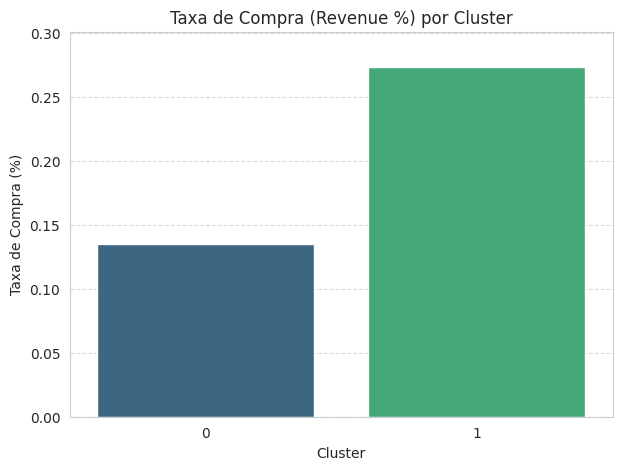

,Taxa de compra (Revenue %)
cluster,
0,0.135092
1,0.273402


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.barplot(x=rev_cluster.index, y='Taxa de compra (Revenue %)', data=rev_cluster, palette='viridis', hue=rev_cluster.index, legend=False)
plt.title('Taxa de Compra (Revenue %) por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Taxa de Compra (%)')
plt.ylim(0, rev_cluster['Taxa de compra (Revenue %)'].max() * 1.1) # Ajusta o limite superior para melhor visualização
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

display(rev_cluster)

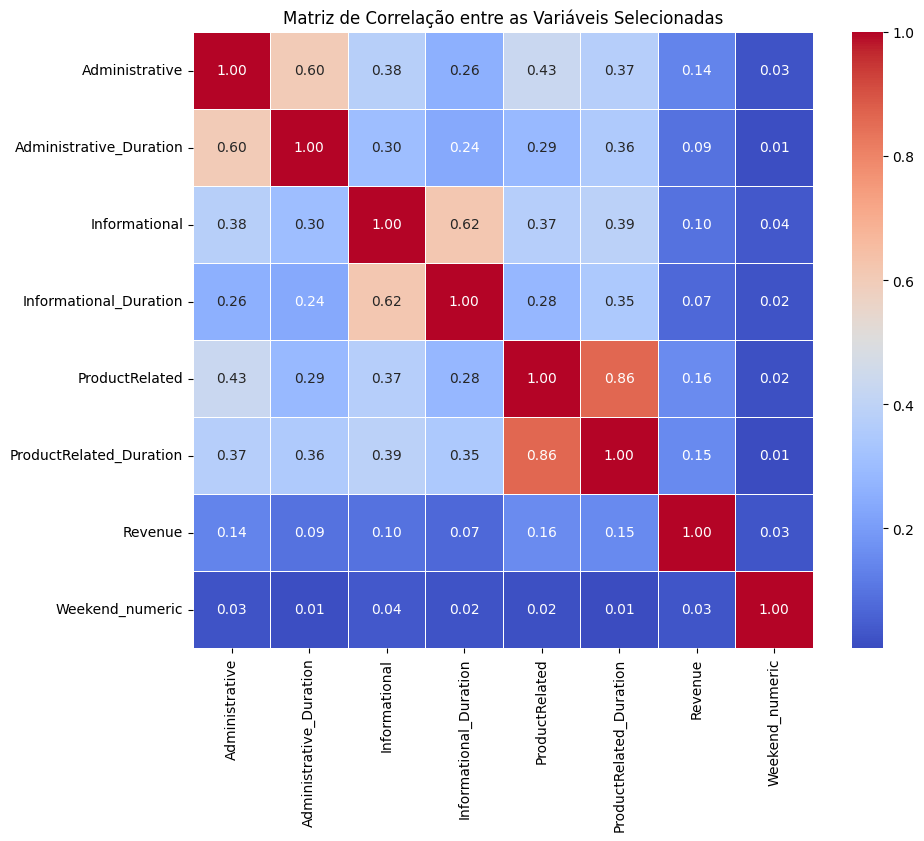

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Incluindo as variáveis de navegação, Revenue e Weekend_numeric
# Garanta que 'Weekend_numeric' seja criada antes, se não estiver já no df
if 'Weekend_numeric' not in df.columns:
    df['Weekend_numeric'] = df['Weekend'].astype(int)

features_for_correlation = cols_navegacao + ['Revenue', 'Weekend_numeric']

# Calcular a matriz de correlação
correlation_matrix = df[features_for_correlation].corr()

# Criar o heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlação entre as Variáveis Selecionadas')
plt.show()

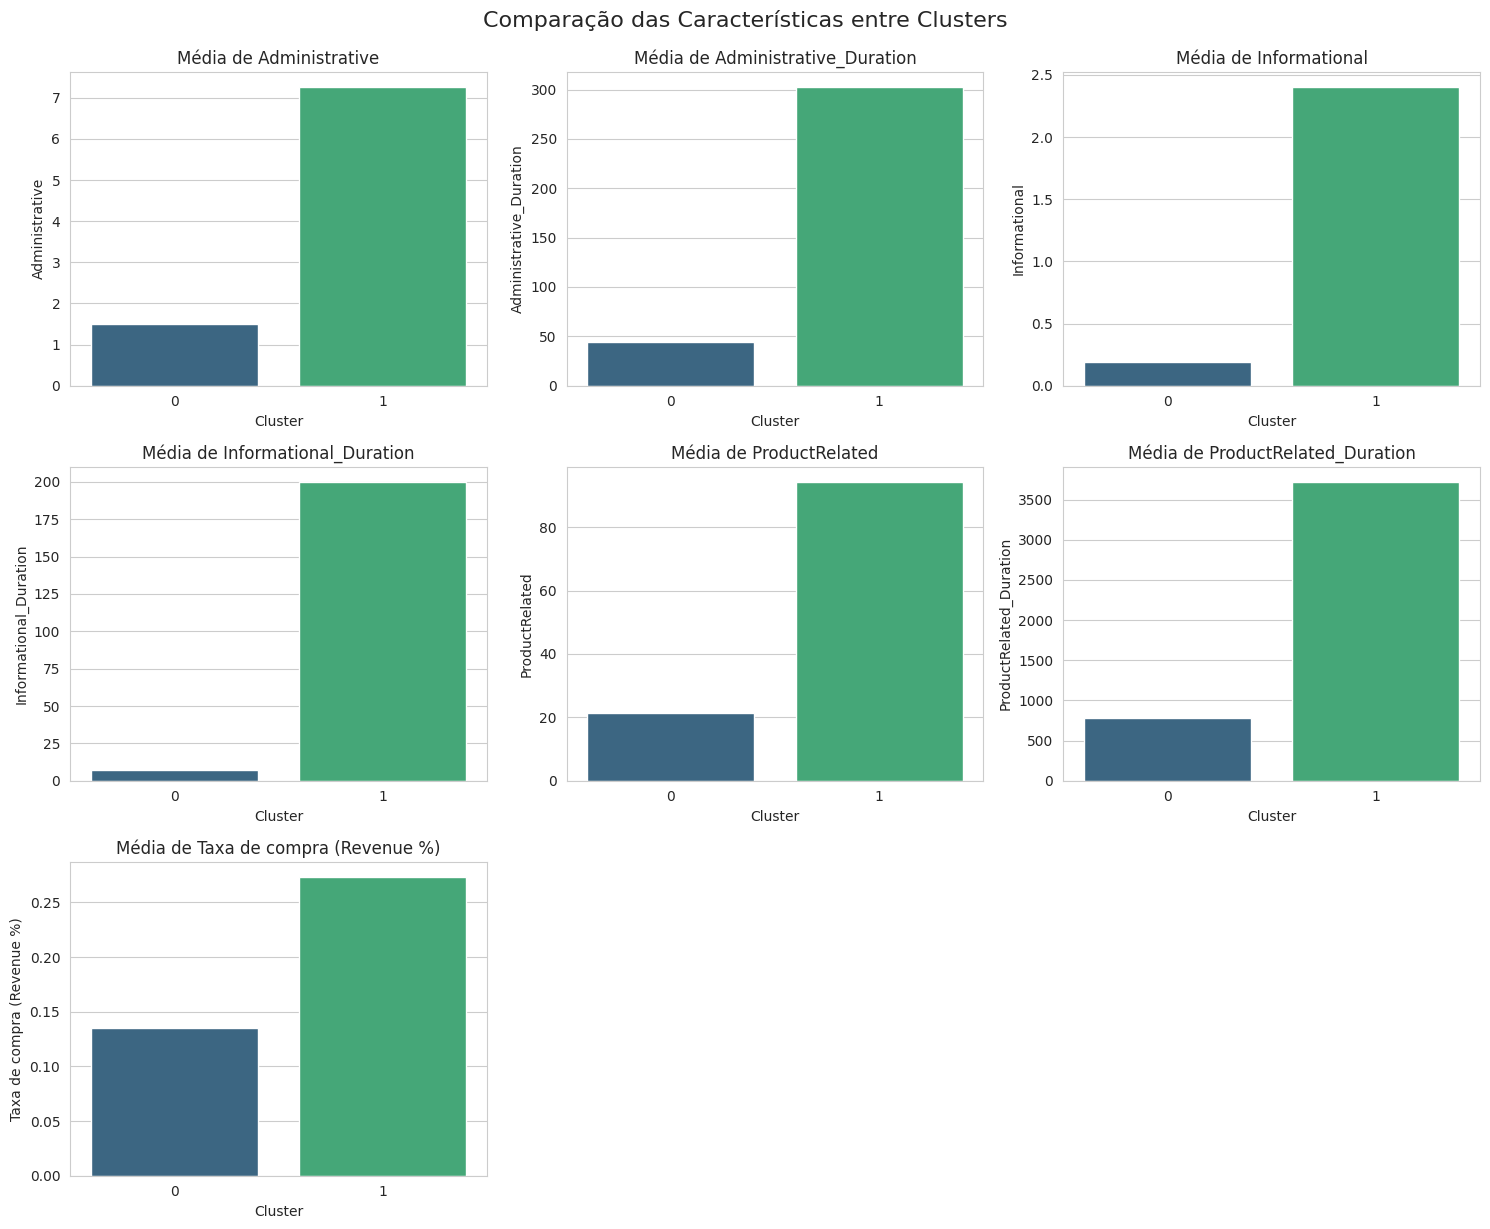

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming cluster_profile_with_revenue is already defined and contains the necessary data
# If not, ensure the preceding cells that create it are run

# Set style for the plots
sns.set_style("whitegrid")

# Get the number of features to plot
num_features = len(cluster_profile_with_revenue.columns)

# Determine grid size for subplots
num_cols = 3 # Number of columns for the subplot grid
num_rows = (num_features + num_cols - 1) // num_cols # Calculate rows needed

plt.figure(figsize=(num_cols * 5, num_rows * 4)) # Adjust figure size dynamically

for i, col in enumerate(cluster_profile_with_revenue.columns):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.barplot(x=cluster_profile_with_revenue.index, y=col, data=cluster_profile_with_revenue, palette='viridis', hue=cluster_profile_with_revenue.index, legend=False)
    plt.title(f'Média de {col}')
    plt.xlabel('Cluster')
    plt.ylabel(col)
    plt.tight_layout()

plt.suptitle('Comparação das Características entre Clusters', y=1.02, fontsize=16)
plt.show()

Perfil médio das variáveis para k = 3:



,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration
cluster_k3,,,,,,
0,6.523289,251.030033,0.973674,42.301835,55.539490,2056.320976
1,7.058201,266.421802,4.086420,458.371554,138.380952,5731.105279
2,0.907898,24.277938,0.160103,6.531608,18.900366,689.114236



Taxa de compra por cluster (k = 3):



,Revenue
cluster_k3,
0,0.231268
1,0.306878
2,0.125134


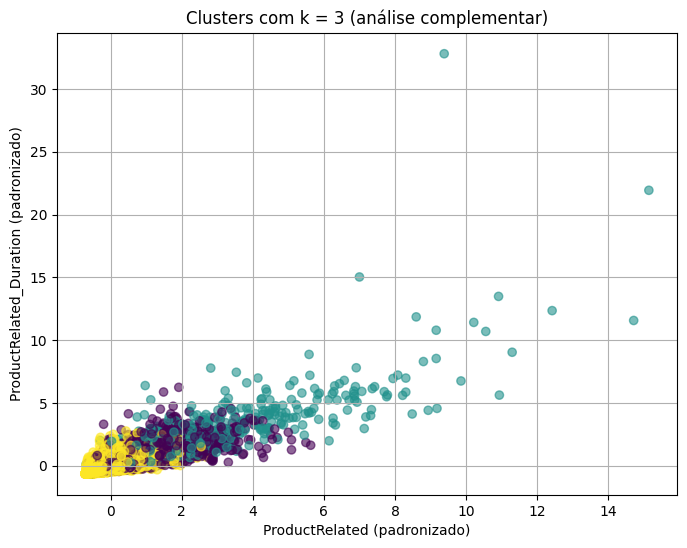

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler # Adicionada importação para StandardScaler

# Re-definindo variáveis necessárias caso o estado do kernel não seja preservado
# 1) CARREGAR O DATASET
try:
    df = pd.read_csv('online_shoppers_intention.csv')
except FileNotFoundError:
    print("Error: 'online_shoppers_intention.csv' not found. Please ensure the file is in the correct directory.")
    raise # Re-raise the error as the notebook cannot proceed without the data

# 2) Seleção das 6 variáveis de navegação
cols_navegacao = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration"
]
X = df[cols_navegacao].copy()

# 3) Padronização (obrigatória para K-means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Ajusta o modelo com 3 clusters
kmeans_k3 = KMeans(n_clusters=3, random_state=42, n_init='auto') # Adicionado n_init='auto' para consistência
labels_k3 = kmeans_k3.fit_predict(X_scaled)

# Adiciona os rótulos ao dataframe TEMPORARIAMENTE (não sobrescreve cluster final)
df["cluster_k3"] = labels_k3

# Perfil descritivo dos clusters com k = 3
cluster_profile_k3 = df.groupby("cluster_k3")[cols_navegacao].mean()
print("Perfil médio das variáveis para k = 3:\n")
display(cluster_profile_k3)

# Distribuição do Revenue em k = 3 (propensão de compra)
print("\nTaxa de compra por cluster (k = 3):\n")
display(df.groupby("cluster_k3")["Revenue"].mean())

# Gráfico simples para visualizar os clusters com k = 3
plt.figure(figsize=(8,6))
plt.scatter(
    X_scaled[:, 4],       # ProductRelated
    X_scaled[:, 5],       # ProductRelated_Duration
    c=labels_k3,
    cmap='viridis',
    alpha=0.6
)
plt.title("Clusters com k = 3 (análise complementar)")
plt.xlabel("ProductRelated (padronizado)")
plt.ylabel("ProductRelated_Duration (padronizado)")
plt.grid(True)
plt.show()

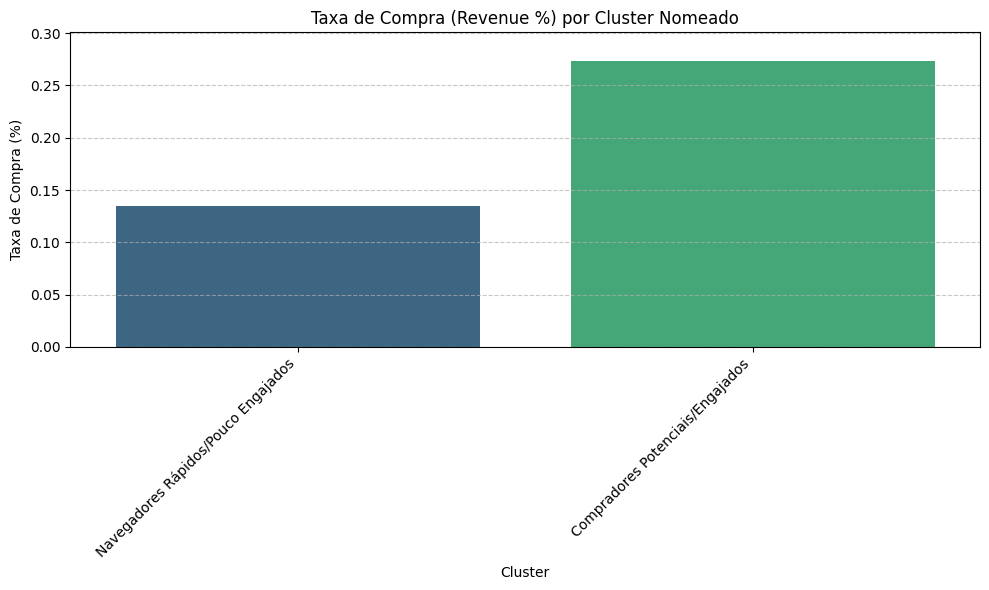

,Taxa de compra (Revenue %),Cluster Name
cluster,,
0,0.135092,Navegadores Rápidos/Pouco Engajados
1,0.273402,Compradores Potenciais/Engajados


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import numpy as np

# --- Start: Ensure df and 'cluster' column are prepared ---

# 1) CARREGAR O DATASET (re-load to ensure fresh state if needed)
try:
    df = pd.read_csv('online_shoppers_intention.csv')
except FileNotFoundError:
    print("Error: 'online_shoppers_intention.csv' not found.")
    raise

# 2) Seleção das 6 variáveis de navegação
cols_navegacao = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration"
]
X = df[cols_navegacao].copy()

# 3) Padronização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4) Re-determine best_k using Silhouette Score (as done in lvG1PT-IktLO)
k_range = range(2, 11)
silhouette_scores = []
for k in k_range:
    labels_temp = KMeans(n_clusters=k, random_state=42, n_init='auto').fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels_temp))
best_k = k_range[np.argmax(silhouette_scores)]

# 5) Ajustar K-means with best_k and assign labels to df
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
labels_final = kmeans_final.fit_predict(X_scaled)
df["cluster"] = labels_final

# --- End: Preparation ---

df['Revenue'] = df['Revenue'].astype(int)

# Calculate rev_cluster
rev_cluster = df.groupby("cluster")['Revenue'].mean().to_frame()
rev_cluster.columns = ["Taxa de compra (Revenue %)"]

# Define cluster names based on the previous analysis (k=2 was the best k, let's stick to that)
cluster_names = {
    0: 'Navegadores Rápidos/Pouco Engajados',
    1: 'Compradores Potenciais/Engajados'
}

# Map cluster IDs to their descriptive names for better visualization labels
rev_cluster_named = rev_cluster.copy()
rev_cluster_named['Cluster Name'] = rev_cluster_named.index.map(cluster_names)

plt.figure(figsize=(10, 6))
sns.barplot(x='Cluster Name', y='Taxa de compra (Revenue %)', hue='Cluster Name', data=rev_cluster_named, palette='viridis', legend=False)
plt.title('Taxa de Compra (Revenue %) por Cluster Nomeado')
plt.xlabel('Cluster')
plt.ylabel('Taxa de Compra (%)')
plt.ylim(0, rev_cluster_named['Taxa de compra (Revenue %)'].max() * 1.1) # Ajusta o limite superior para melhor visualização
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(rev_cluster_named)

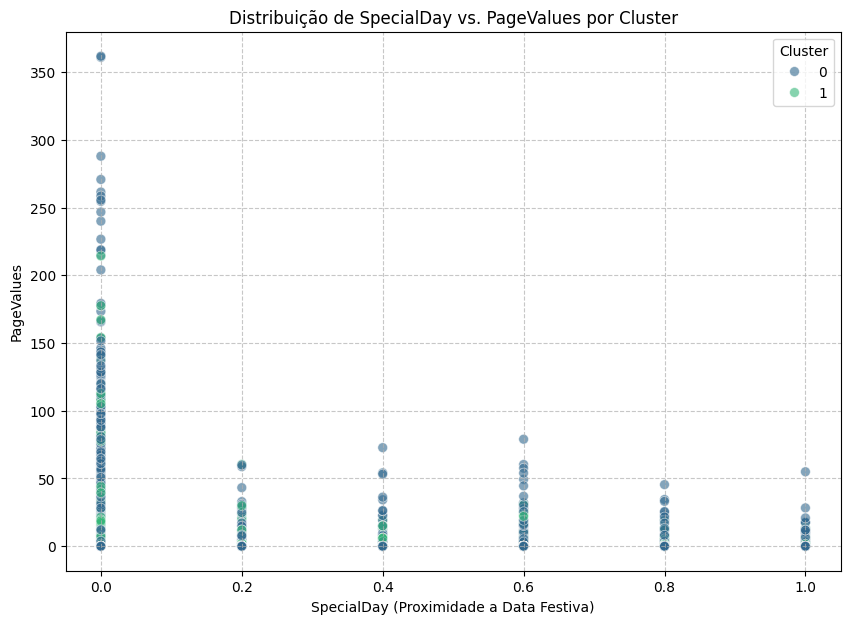

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x='SpecialDay', y='PageValues', hue='cluster', data=df, palette='viridis', s=50, alpha=0.6)
plt.title('Distribuição de SpecialDay vs. PageValues por Cluster')
plt.xlabel('SpecialDay (Proximidade a Data Festiva)')
plt.ylabel('PageValues')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Cluster')
plt.show()

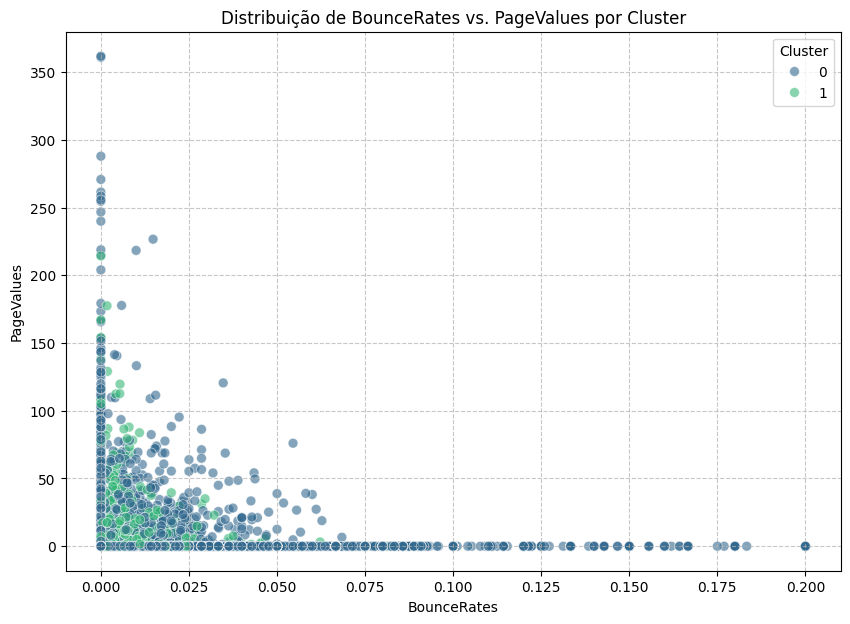

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x='BounceRates', y='PageValues', hue='cluster', data=df, palette='viridis', s=50, alpha=0.6)
plt.title('Distribuição de BounceRates vs. PageValues por Cluster')
plt.xlabel('BounceRates')
plt.ylabel('PageValues')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Cluster')
plt.show()

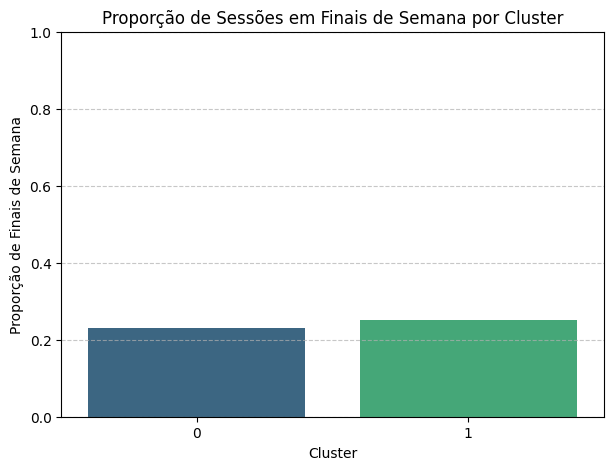

,cluster,Proporção de Finais de Semana (%)
0,0,0.229628
1,1,0.250571


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'Weekend' to numerical (0 for False, 1 for True)
df['Weekend_numeric'] = df['Weekend'].astype(int)

# Calculate the proportion of weekend sessions per cluster
weekend_by_cluster = df.groupby('cluster')['Weekend_numeric'].mean().reset_index()
weekend_by_cluster.columns = ['cluster', 'Proporção de Finais de Semana (%)']

# Create the bar plot
plt.figure(figsize=(7, 5))
sns.barplot(x='cluster', y='Proporção de Finais de Semana (%)', hue='cluster', data=weekend_by_cluster, palette='viridis', legend=False)
plt.title('Proporção de Sessões em Finais de Semana por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Proporção de Finais de Semana')
plt.ylim(0, 1) # Set y-axis limit from 0 to 1 for proportions
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

display(weekend_by_cluster)

Month,Aug,Dec,Feb,Jul,June,Mar,May,Nov,Oct,Sep
cluster,,,,,,,,,,
0,0.033938,0.142749,0.017016,0.035451,0.023350,0.163074,0.284647,0.221403,0.043014,0.035356
1,0.042237,0.123858,0.002283,0.032534,0.023402,0.103881,0.201484,0.374429,0.053653,0.042237


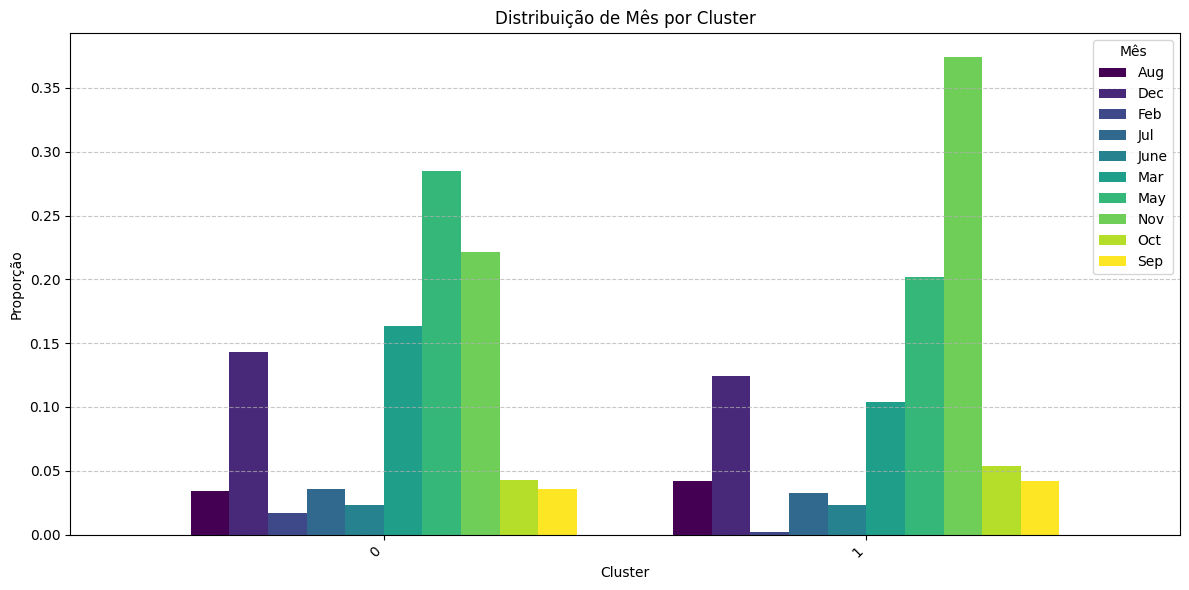

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the distribution of Month within each cluster
month_distribution = df.groupby('cluster')['Month'].value_counts(normalize=True).unstack(fill_value=0)

# Display the distribution
display(month_distribution)

# Plot the distribution
month_distribution.plot(kind='bar', figsize=(12, 6), cmap='viridis', width=0.8)
plt.title('Distribuição de Mês por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Proporção')
plt.xticks(rotation=45, ha='right') # Ensure x-axis labels are readable
plt.legend(title='Mês')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

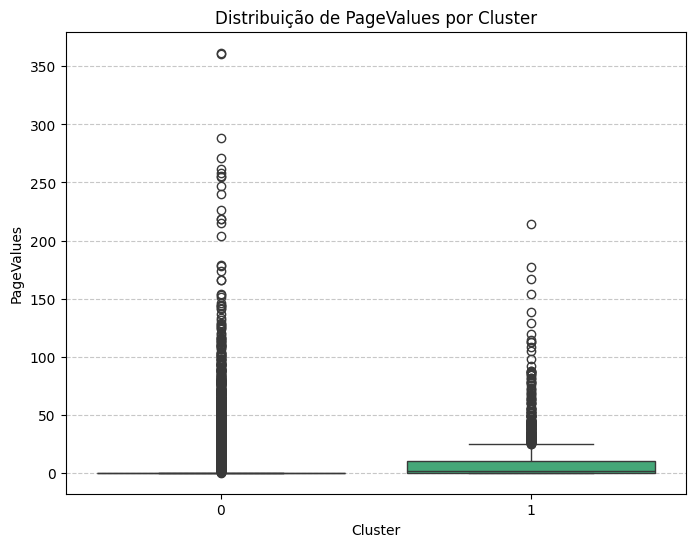

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='cluster', y='PageValues', data=df, palette='viridis', hue='cluster', legend=False)
plt.title('Distribuição de PageValues por Cluster')
plt.xlabel('Cluster')
plt.ylabel('PageValues')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

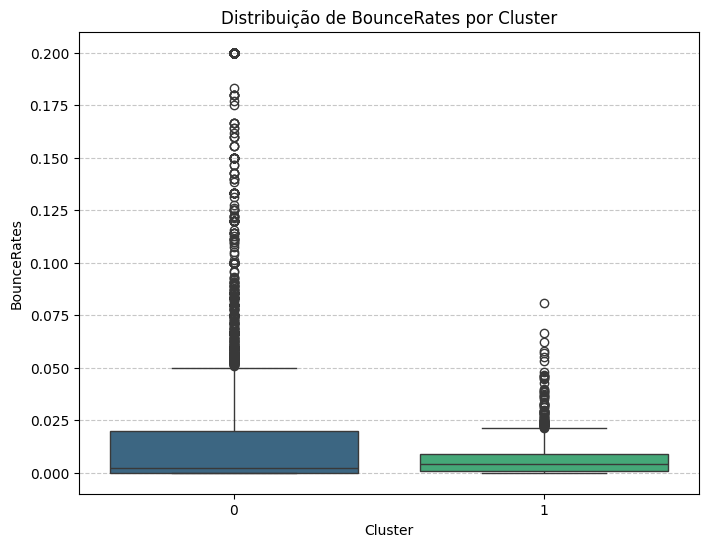

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='cluster', y='BounceRates', data=df, palette='viridis', hue='cluster', legend=False)
plt.title('Distribuição de BounceRates por Cluster')
plt.xlabel('Cluster')
plt.ylabel('BounceRates')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Análise de 'BounceRates' por Cluster

O boxplot de 'BounceRates' (taxa de rejeição) por cluster demonstra o seguinte:

*   **Cluster 0 ('Navegadores Rápidos/Pouco Engajados')**: Apresenta taxas de rejeição consideravelmente mais altas, com a mediana e os quartis superiores mostrando que uma grande proporção de sessões neste cluster tem alta probabilidade de "saltar" do site após visitar apenas uma página. Isso reforça a ideia de baixo engajamento.
*   **Cluster 1 ('Compradores Potenciais/Engajados')**: Possui taxas de rejeição muito mais baixas e concentradas em valores próximos de zero. Isso indica que os usuários neste cluster tendem a interagir com múltiplas páginas e não "saltam" rapidamente do site, o que é consistente com o perfil de alto engajamento e propensão à compra.

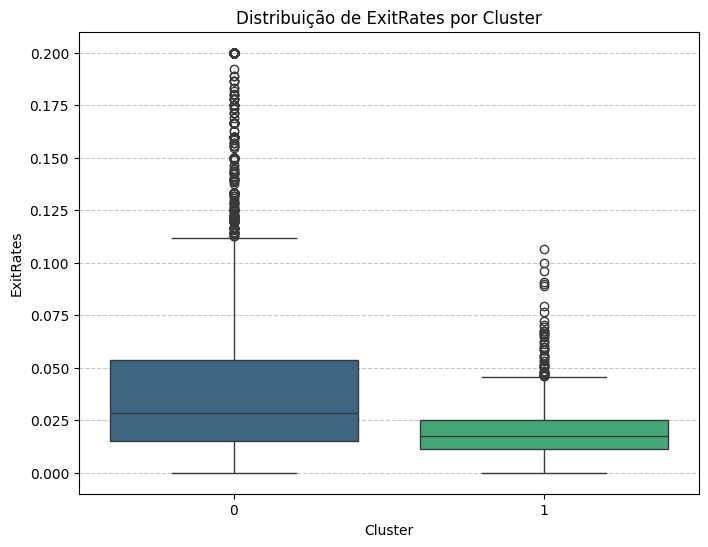

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='cluster', y='ExitRates', data=df, palette='viridis', hue='cluster', legend=False)
plt.title('Distribuição de ExitRates por Cluster')
plt.xlabel('Cluster')
plt.ylabel('ExitRates')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##**Análise Descritiva**

Dimensão da base:
(12330, 18)

Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


,Month,VisitorType
count,12330,12330
unique,10,3
top,May,Returning_Visitor
freq,3364,10551


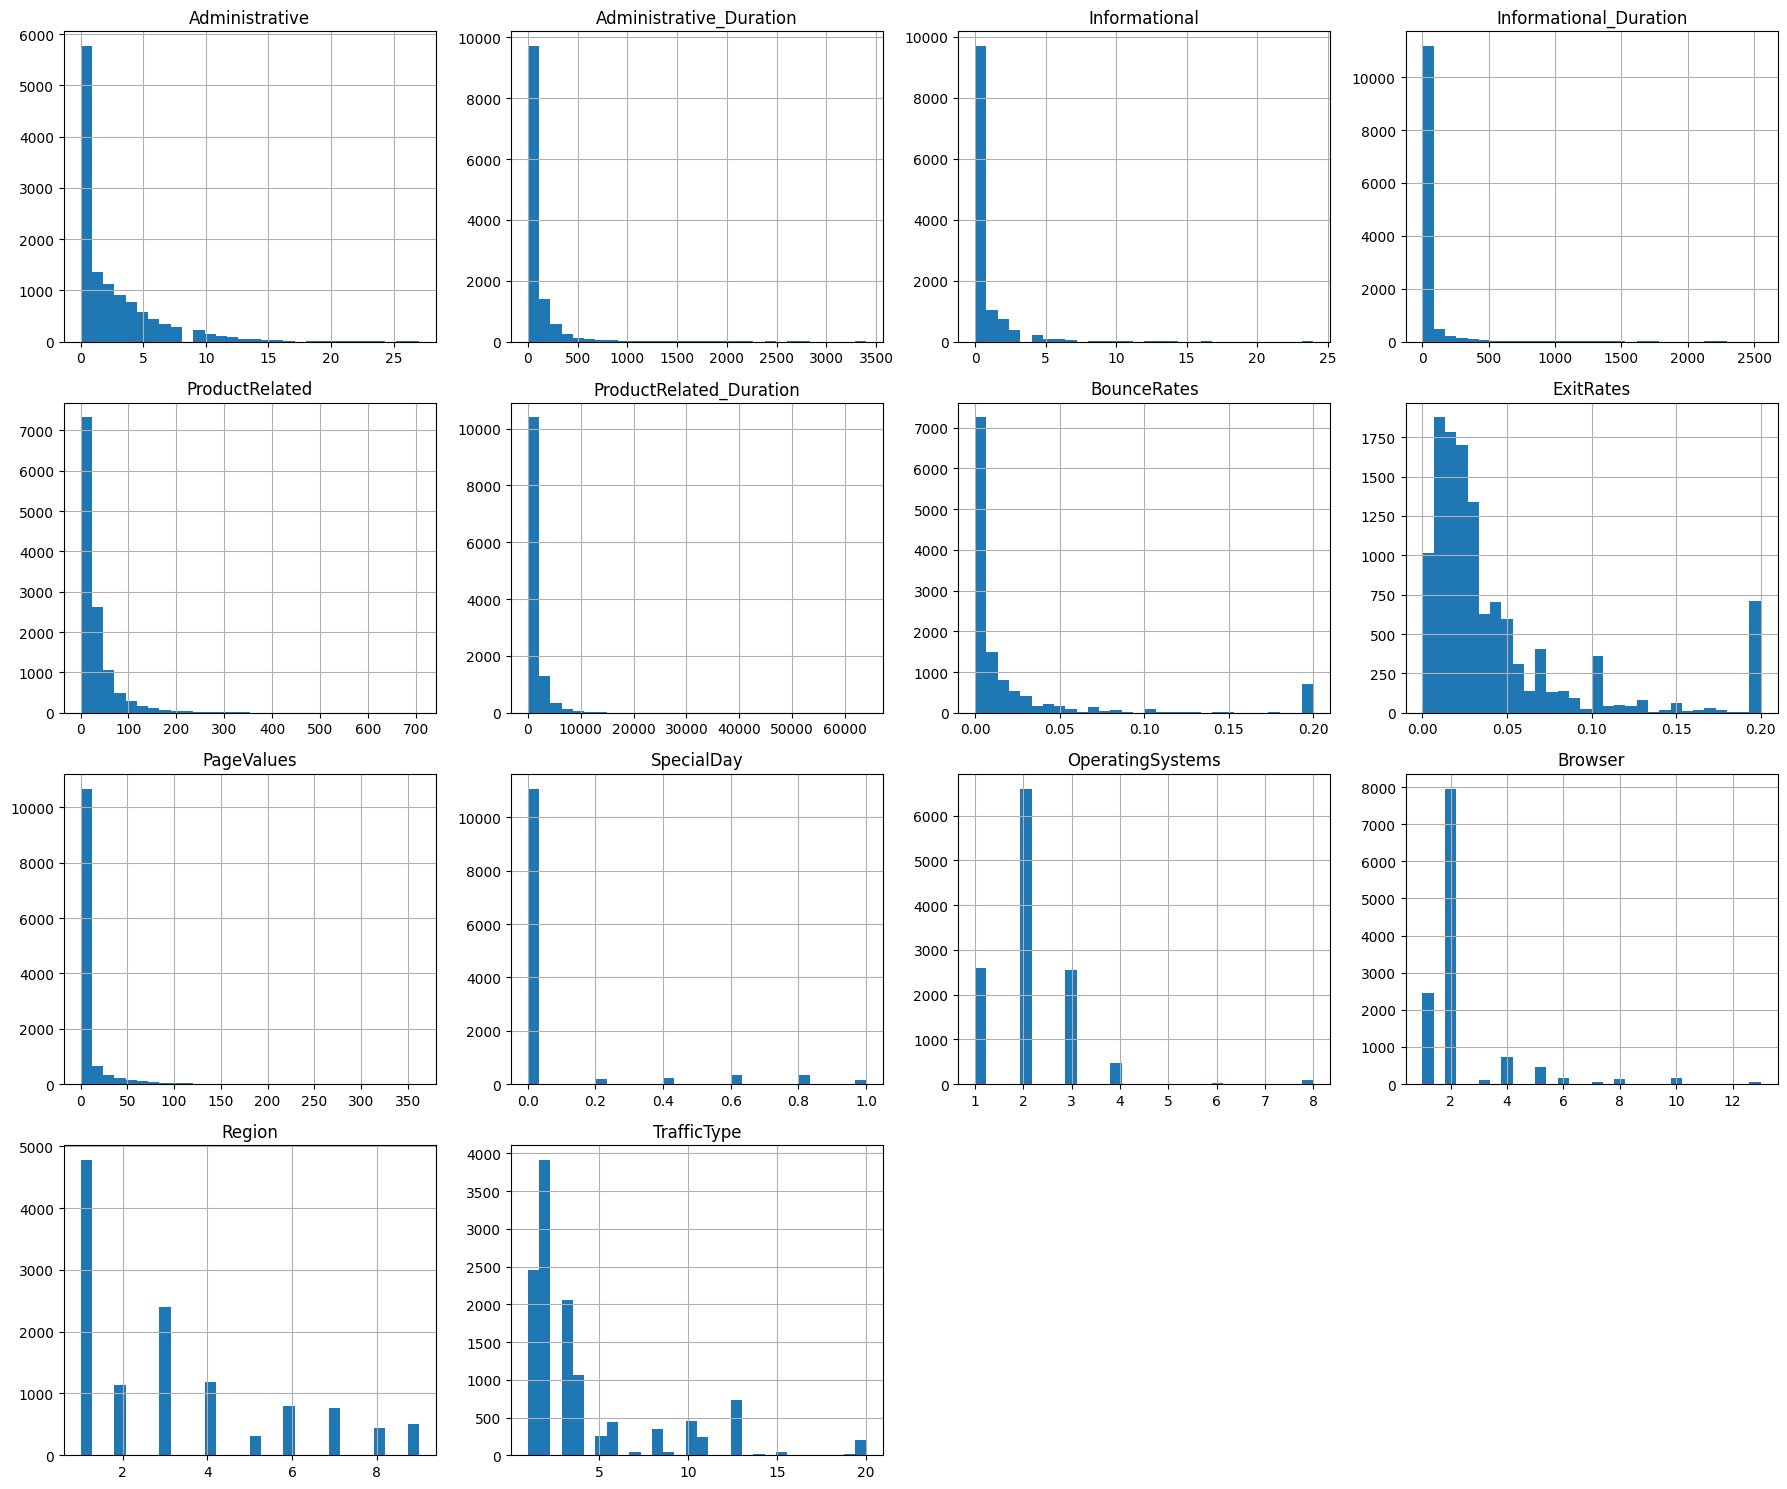

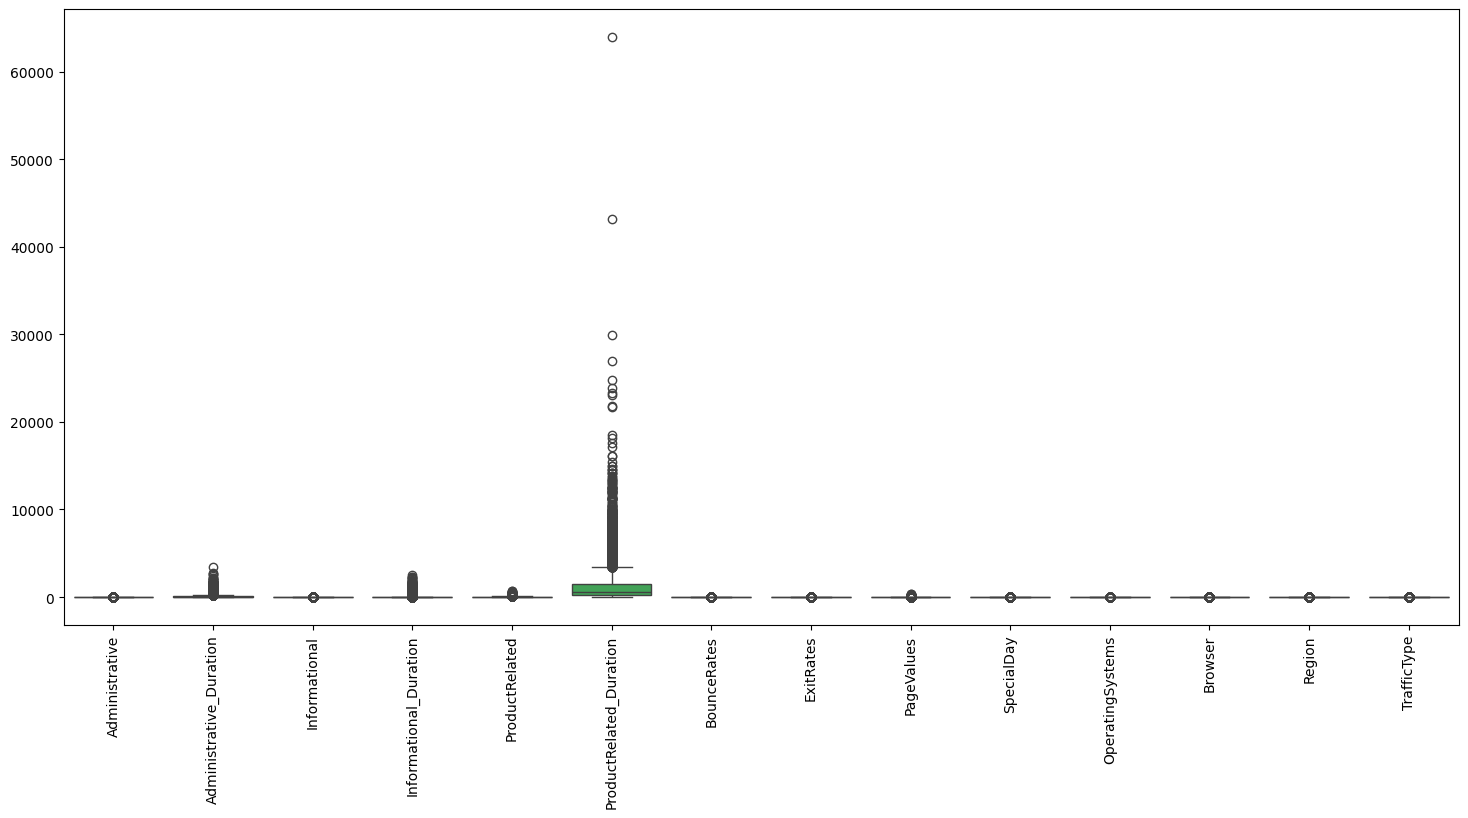

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Import pandas to read the CSV and create the DataFrame

# Load the dataset to define 'df'
try:
    df = pd.read_csv('online_shoppers_intention.csv')
except FileNotFoundError:
    print("Error: 'online_shoppers_intention.csv' not found. Please ensure the file is in the correct directory.")
    raise # Re-raise the error to stop execution and prevent further NameErrors

print('Dimensão da base:')
print(df.shape)

print('\nInformações gerais:')
df.info()

print('\nValores ausentes:')
display(df.isnull().sum())

display(df.describe())

display(df.describe(include='object'))

num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(
    figsize=(18,15),
    bins=30
)

plt.tight_layout()
plt.show()

plt.figure(figsize=(18,8))
sns.boxplot(data=df[num_cols])

plt.xticks(rotation=90)
plt.show()

**Variáveis de Agrupamento**

In [ ]:
from sklearn.preprocessing import StandardScaler

vars_cluster = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'PageValues',
    'SpecialDay',
    'Month',
    'VisitorType',
    'Weekend'
]

cluster = df[vars_cluster].copy()

cluster = pd.get_dummies(
    cluster,
    columns=['Month','VisitorType'],
    drop_first=True
)

cluster['Weekend'] = cluster['Weekend'].astype(int)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(cluster)

print(X_scaled.shape)

(12330, 20)


**Agrupamentos Hierárquicos**

In [ ]:
from sklearn.cluster import AgglomerativeClustering

modelo3 = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

df['Cluster_3'] = modelo3.fit_predict(X_scaled)

modelo4 = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward'
)

df['Cluster_4'] = modelo4.fit_predict(X_scaled)

print('Distribuição dos grupos - 3 clusters')
display(df['Cluster_3'].value_counts())

print('Distribuição dos grupos - 4 clusters')
display(df['Cluster_4'].value_counts())

print('Perfil dos grupos - 3 clusters')

display(
    df.groupby('Cluster_3')[
        [
            'Administrative',
            'Informational',
            'ProductRelated',
            'PageValues'
        ]
    ].mean()
)

print('Perfil dos grupos - 4 clusters')

display(
    df.groupby('Cluster_4')[
        [
            'Administrative',
            'Informational',
            'ProductRelated',
            'PageValues'
        ]
    ].mean()
)

Distribuição dos grupos - 3 clusters


,count
Cluster_3,
0,7979
1,3480
2,871


Distribuição dos grupos - 4 clusters


,count
Cluster_4,
0,6216
1,3480
3,1763
2,871


Perfil dos grupos - 3 clusters


,Administrative,Informational,ProductRelated,PageValues
Cluster_3,,,,
0,2.075323,0.332498,26.399799,6.823301
1,1.673276,0.320115,24.998851,3.649241
2,7.076923,2.803674,107.473020,6.282519


Perfil dos grupos - 4 clusters


,Administrative,Informational,ProductRelated,PageValues
Cluster_4,,,,
0,2.227156,0.378861,28.908623,7.816056
1,1.673276,0.320115,24.998851,3.649241
2,7.076923,2.803674,107.473020,6.282519
3,1.539989,0.169030,17.554169,3.323035


**Avaliação dos Resultados**

In [ ]:
print('Revenue por grupo - 3 clusters')

display(
    pd.crosstab(
        df['Cluster_3'],
        df['Revenue'],
        normalize='index'
    ) * 100
)

print('Bounce Rate médio - 3 clusters')

display(
    df.groupby('Cluster_3')['BounceRates'].mean()
)

print('Revenue por grupo - 4 clusters')

display(
    pd.crosstab(
        df['Cluster_4'],
        df['Revenue'],
        normalize='index'
    ) * 100
)

print('Bounce Rate médio - 4 clusters')

display(
    df.groupby('Cluster_4')['BounceRates'].mean())

Revenue por grupo - 3 clusters


Revenue,False,True
Cluster_3,,
0,83.393909,16.606091
1,91.264368,8.735632
2,67.967853,32.032147


Bounce Rate médio - 3 clusters


,BounceRates
Cluster_3,
0,0.020539
1,0.029919
2,0.006455


Revenue por grupo - 4 clusters


Revenue,False,True
Cluster_4,,
0,81.081081,18.918919
1,91.264368,8.735632
2,67.967853,32.032147
3,91.548497,8.451503


Bounce Rate médio - 4 clusters


,BounceRates
Cluster_4,
0,0.019808
1,0.029919
2,0.006455
3,0.023115


**Conclusão**

A aplicação da técnica de Clusterização Hierárquica permitiu segmentar os visitantes do e-commerce em grupos com comportamentos distintos de navegação e intenção de compra. A análise considerou variáveis relacionadas ao tipo de página visitada, tempo de permanência, proximidade de datas especiais, comportamento de saída e valor gerado pelas páginas.

Os resultados demonstraram que o comportamento dos consumidores não é homogêneo, existindo grupos com forte intenção de compra e outros que utilizam o site principalmente para pesquisa de informações. As variáveis relacionadas às páginas de produtos e ao tempo de navegação apresentaram grande influência na formação dos clusters, indicando que consumidores mais engajados tendem a explorar um maior número de produtos e permanecer mais tempo no site.

Também foi possível observar que fatores temporais, como proximidade de datas especiais e períodos do ano, exercem influência sobre o comportamento dos usuários. Visitantes que acessam o site em momentos próximos a datas comemorativas apresentam padrões de navegação distintos, frequentemente associados a maior intenção de compra.

A clusterização demonstrou ser uma ferramenta eficaz para identificar segmentos de consumidores, permitindo que a empresa personalize campanhas de marketing, otimize a experiência do usuário e desenvolva estratégias específicas para cada perfil identificado.

**Insights**


Criar campanhas específicas para visitantes com alta intenção de compra.
Implementar ações de remarketing para usuários que visitam produtos mas não convertem.
Reforçar promoções em períodos próximos a datas especiais.
Melhorar páginas com altas taxas de saída.
Investir em conteúdo informativo para apoiar o processo de decisão.
Personalizar ofertas de acordo com o perfil identificado em cada cluster.
Desenvolver estratégias específicas para visitantes recorrentes e novos visitantes.